# PSUPR Clustering Submission Workshop

 - Objective: Understanding and Profiling Staff Attrition using cluster techniques
 - July 2025

In [1]:
#check environment and kernel
import sys
print(sys.executable)

/hpctmp/e1554287/conda/envs/ai1008/bin/python


In [2]:
!conda info --envs

# conda environments:
#
base                     /app1/ebapps/arches/flat-avx2/software/Anaconda3/2023.09-0
ai1008                *  /hpctmp/e1554287/conda/envs/ai1008
tf312                    /hpctmp/e1554287/conda/envs/tf312



In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import warnings
warnings.filterwarnings("ignore")

# 1. Import Data

In [2]:
# For this workshop ... download the data from
# https://www.kaggle.com/datasets/pavansubhasht/ibm-hr-analytics-attrition-dataset

done:\
```
$ ~/projects/ideal-ML-train/pattern-recognition$ curl -L -o ./ibm-hr-analytics-attrition-dataset.zip  https://www.kaggle.com/api/v1/datasets/download/pavansubhasht/ibm-hr-analytics-attrition-dataset
  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
  0     0    0     0    0     0      0      0 --:--:-- --:--:-- --:--:--     0
100 51314  100 51314    0     0  68961      0 --:--:-- --:--:-- --:--:-- 1181k
$ ~/projects/ideal-ML-train/pattern-recognition$ unzip ibm-hr-analytics-attrition-dataset.zip
Archive:  ibm-hr-analytics-attrition-dataset.zip
  inflating: WA_Fn-UseC_-HR-Employee-Attrition.csv
```

In [10]:
# -----------------------------------------------------------
# 0) Imports, config, and data load
# -----------------------------------------------------------

# Import standard libraries
import os  # for file path checks and directory creation
import sys  # for Python version and path info
import numpy as np  # for numerical operations
import pandas as pd  # for data manipulation

# Import plotting library (matplotlib only, avoid plotly for GitHub PNGs)
import matplotlib.pyplot as plt  # for plotting charts

# Plotting defaults (avoid specifying explicit colors; keep figures separate)
plt.rcParams["figure.figsize"] = (8, 5)  # set a compact default figure size
plt.rcParams["axes.grid"] = True  # light grid to aid reading

# Ensure a folder exists to save figures for GitHub rendering
os.makedirs("figs", exist_ok=True)  # create a 'figs' directory if it doesn't exist

# Path to your dataset (adjust if needed)
csv_path = "WA_Fn-UseC_-HR-Employee-Attrition.csv"  # file expected in current working directory

# Load the dataset with safe fallback
if not os.path.exists(csv_path):  # check if file exists at the given path
    raise FileNotFoundError(f"CSV not found at {csv_path}. Please update 'csv_path' to the correct location.")  # clear error

df_raw = pd.read_csv(csv_path)  # read the CSV into a DataFrame
df = df_raw.copy()  # keep a pristine copy for reference later
print(df.shape)  # quick shape check to ensure load worked
df.head()  # quick peek at the first few rows

(1470, 35)


,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


### Quick sanity checks and EDA

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EmployeeCount             1470 non-null   int64 
 9   EmployeeNumber            1470 non-null   int64 
 10  EnvironmentSatisfaction   1470 non-null   int64 
 11  Gender                    1470 non-null   object
 12  HourlyRate                1470 non-null   int64 
 13  JobInvolvement            1470 non-null   int64 
 14  JobLevel                

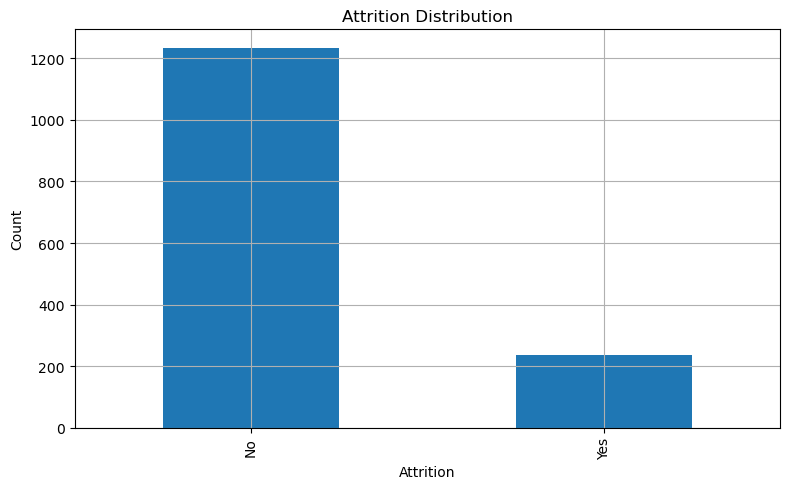

In [11]:
# -----------------------------------------------------------
# 1) Quick sanity checks & basic EDA visuals
# -----------------------------------------------------------

# Show basic info for types and nulls
df.info()  # column types and non-null counts

# Null heatmap proxy: bar chart of missing counts (matplotlib only)
missing_counts = df.isna().sum()  # count missing values per column
missing_counts = missing_counts[missing_counts > 0]  # focus on columns that have missing
if len(missing_counts) > 0:  # only plot if there are missing values
    missing_counts.sort_values(ascending=False).plot(kind="bar")  # bar plot of missing counts
    plt.title("Missing Values per Column")  # title
    plt.ylabel("Count of Missing")  # y label
    plt.tight_layout()  # tidy layout
    plt.savefig("figs/missing_values.png", bbox_inches="tight", dpi=150)  # save PNG
    plt.show()  # render inline
else:
    print("No missing values detected.")  # concise message if no missing

# Basic target distribution (if 'Attrition' exists)
if "Attrition" in df.columns:  # check that the expected column exists
    df["Attrition"].value_counts().plot(kind="bar")  # bar plot of attrition counts
    plt.title("Attrition Distribution")  # title
    plt.ylabel("Count")  # y label
    plt.tight_layout()  # tidy layout
    plt.savefig("figs/attrition_distribution.png", bbox_inches="tight", dpi=150)  # save PNG
    plt.show()  # render inline

Reflection — Q: Should **un**supervised clustering consider the ‘Attrition’ label?\
A: Do not use it for fitting (to avoid leakage), but we may profile clusters against it later to assess usefulness.

# 2. Variance Threshold

 - There are a few columns with low or zero variance.
 - You should remove them.
 - Note: You need to identify categorcial and numerical features to check for variance 

In [7]:
# Import variance threshold for low/zero variance filtering
from sklearn.feature_selection import VarianceThreshold  # remove zero/low variance numeric features


In [12]:
# -----------------------------------------------------------
# 2) Identify numeric vs categorical; remove zero/low-variance columns
# -----------------------------------------------------------

# Identify numeric and categorical columns by dtype
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()  # numeric columns
categorical_cols = df.select_dtypes(exclude=[np.number]).columns.tolist()  # non-numeric columns

# Some columns in this dataset are known constants/IDs; remove them early to avoid noise.
# These are commonly near-constant in IBM HR dataset: 'EmployeeCount', 'Over18', 'StandardHours', 'EmployeeNumber'
# We'll drop if present.
drop_if_present = ["EmployeeCount", "Over18", "StandardHours", "EmployeeNumber"]  # known non-informative columns
actually_dropped = [c for c in drop_if_present if c in df.columns]  # intersect with actual columns in df
df = df.drop(columns=actually_dropped)  # drop them
if actually_dropped:  # message on what was removed
    print("Dropped known non-informative columns:", actually_dropped)  # print dropped list

# Recompute dtypes after dropping
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()  # update numeric col list
categorical_cols = df.select_dtypes(exclude=[np.number]).columns.tolist()  # update categorical col list

# Remove zero-variance numeric columns with VarianceThreshold
if numeric_cols:  # only if numeric columns exist
    vt = VarianceThreshold(threshold=0.0)  # threshold=0.0 removes exactly constant columns
    _ = vt.fit(df[numeric_cols])  # fit VT on numeric subset
    keep_mask = vt.get_support()  # boolean mask of columns to keep
    removed_zero_var = [col for col, keep in zip(numeric_cols, keep_mask) if not keep]  # list removed
    if removed_zero_var:  # only report if something is removed
        print("Numeric zero-variance removed:", removed_zero_var)  # print removed list
    numeric_cols = [col for col, keep in zip(numeric_cols, keep_mask) if keep]  # keep only useful ones

# Additional heuristic: drop near-zero variance categorical columns (dominant single level)
# We'll compute the top-level frequency ratio and drop if > 0.99 (tunable)
near_zero_cat = []  # list to collect categorical columns to drop
for c in categorical_cols:  # iterate each categorical column
    vc = df[c].value_counts(dropna=False)  # frequency of each category including NaN
    if len(vc) <= 1:  # single unique level
        near_zero_cat.append(c)  # mark for drop
    else:
        top_ratio = (vc.iloc[0] / vc.sum())  # top category frequency ratio
        if top_ratio > 0.99:  # if 99%+ same value, consider it near-constant
            near_zero_cat.append(c)  # mark for drop

# Drop identified near-zero variance categorical columns
if near_zero_cat:  # if there are any to drop
    print("Categorical near-zero-variance removed:", near_zero_cat)  # print list
    df = df.drop(columns=near_zero_cat)  # drop from df

# Update lists again post-drops
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()  # refresh numeric list
categorical_cols = df.select_dtypes(exclude=[np.number]).columns.tolist()  # refresh categorical list

# Quick printout of what remains
print(f"Numeric features retained: {len(numeric_cols)}")  # count numeric
print(f"Categorical features retained: {len(categorical_cols)}")  # count categorical


Dropped known non-informative columns: ['EmployeeCount', 'Over18', 'StandardHours', 'EmployeeNumber']
Numeric features retained: 23
Categorical features retained: 8


Reflection — Q: Is VarianceThreshold enough?\
A: It handles zero variance numerics. For low variance or categorical dominance, we added a top-ratio heuristic; you can tighten/loosen the 0.99 threshold per need.

# 3. Encode Categorical Variables

In [15]:
# Import sklearn utilities for preprocessing and modeling
from sklearn.impute import SimpleImputer  # to handle missing values
from sklearn.preprocessing import OneHotEncoder  # to encode categorical variables
from sklearn.compose import ColumnTransformer  # to build preprocessing pipelines
from sklearn.pipeline import Pipeline  # to chain steps cleanly

# from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

# -----------------------------------------------------------
# 3) Preprocessing pipelines (OHE for categoricals, scaling for numerics)
# -----------------------------------------------------------

# Build the numeric pipeline: impute missing with median, then standardize (mean=0, std=1) for KMeans
numeric_pipe = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),  # robust to skew
    ("scaler", StandardScaler())  # standardize for KMeans distance stability
])  # end numeric pipeline

# Build the categorical pipeline: impute missing with most frequent, then OneHotEncode
categorical_pipe = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),  # fill missing with mode
    ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))  # dense array for PCA later
])  # end categorical pipeline

# ColumnTransformer to apply the right pipeline to each feature subset
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_pipe, numeric_cols),  # numeric branch
        ("cat", categorical_pipe, categorical_cols)  # categorical branch
    ],
    remainder="drop"  # drop anything else that sneaks in
)  # end ColumnTransformer

# Fit-transform the preprocessor to obtain the model matrix for clustering
X = preprocessor.fit_transform(df)  # fit on df and transform to numeric matrix
print("Transformed matrix shape:", X.shape)  # show resulting dimensionality



Transformed matrix shape: (1470, 53)


Reflection — Q: Why not LabelEncoder for categoricals here?\
A: LabelEncoder imposes arbitrary ordinal distances. For KMeans, OneHotEncoder avoids fake orderings and preserves category separation.

##### still, to use LabelEncoder:

In [ ]:
# -----------------------------------------------------------
# 3) Preprocessing pipelines (OHE for categoricals, scaling for numerics)
# Version-safe handling of OneHotEncoder 'sparse' vs 'sparse_output'
# -----------------------------------------------------------

from sklearn.impute import SimpleImputer            # imputation for missing values
from sklearn.preprocessing import OneHotEncoder     # one-hot for categoricals
from sklearn.preprocessing import StandardScaler    # standardization for numerics
from sklearn.compose import ColumnTransformer       # apply pipelines by column type
from sklearn.pipeline import Pipeline               # chain steps
from sklearn import __version__ as skver            # grab sklearn version string

# Decide which kwarg to use for dense output from OHE based on sklearn version
major, minor = map(int, skver.split(".")[:2])       # parse major.minor, e.g., "1.4" -> (1, 4)
ohe_dense_kw = {"handle_unknown": "ignore"}         # always ignore unseen categories at transform time
if (major > 1) or (major == 1 and minor >= 2):      # sklearn >= 1.2 uses 'sparse_output'
    ohe_dense_kw["sparse_output"] = False           # request dense numpy array output
else:                                               # sklearn < 1.2 used 'sparse'
    ohe_dense_kw["sparse"] = False                  # request dense numpy array output

# Numeric pipeline: impute median then standardize (better for distance-based methods)
numeric_pipe = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),  # median is robust to skew/outliers
    ("scaler", StandardScaler())                    # zero-mean unit-variance for KMeans stability
])  # end numeric pipeline

# Categorical pipeline: impute most frequent then one-hot encode (dense)
categorical_pipe = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),       # fill missing with mode
    ("onehot", OneHotEncoder(**ohe_dense_kw))                   # use version-safe dense OHE
])  # end categorical pipeline

# Column-wise preprocessor: apply numeric and categorical branches
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_pipe, numeric_cols),  # numeric columns go through numeric_pipe
        ("cat", categorical_pipe, categorical_cols)  # categorical columns go through categorical_pipe
    ],
    remainder="drop"  # drop any columns not listed (safer than passthrough)
)  # end ColumnTransformer

# Fit and transform to get the model matrix for clustering
X = preprocessor.fit_transform(df)               # learn imputers/encoders/scalers and transform data
print("Transformed matrix shape:", X.shape)      # confirm the final feature dimension


# 4. Kmeans clustering
 - Use the scree plot to find the "optimal" number of clusters

In [17]:
# Import clustering and metrics
from sklearn.cluster import KMeans  # KMeans clustering
from sklearn.metrics import silhouette_score, silhouette_samples  # for cluster quality


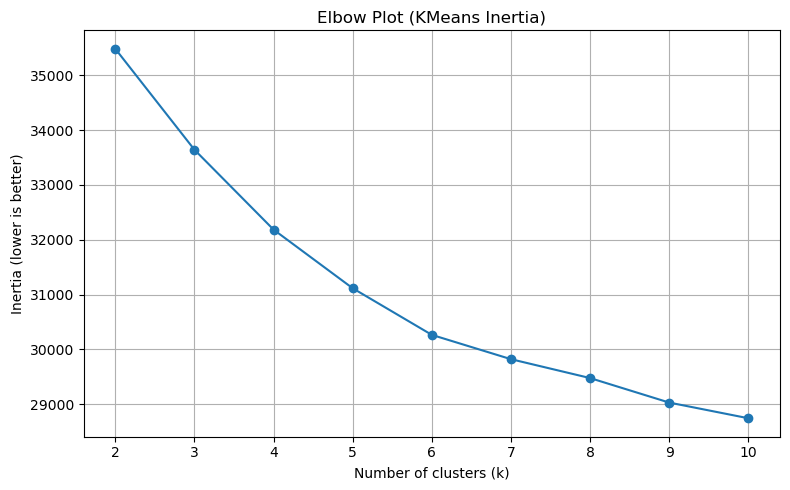

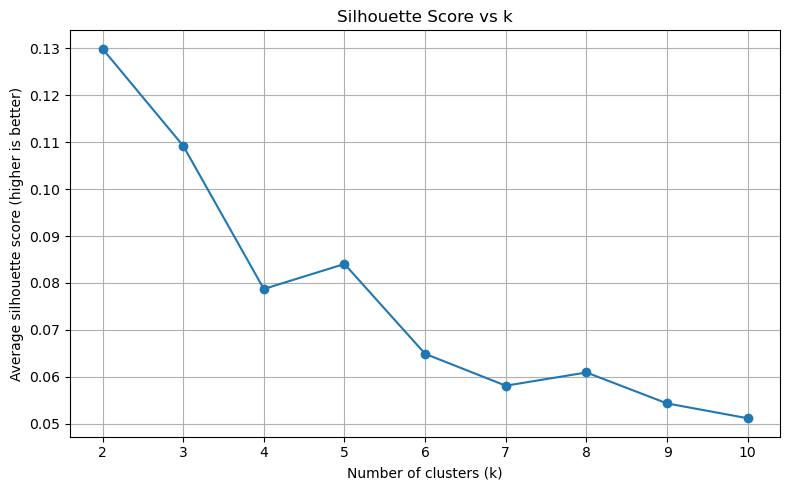

Chosen k (by silhouette): 2


In [18]:
# -----------------------------------------------------------
# 4) Choose K via Elbow (inertia) and Silhouette; visualize both
# -----------------------------------------------------------

# Define a reasonable K search space (tune if you expect many clusters)
k_range = range(2, 11)  # try k from 2 to 10 inclusive

# Containers for metrics
inertias = []  # KMeans objective (sum of squared distances)
sil_scores = []  # silhouette scores

# Loop across candidate k, fit KMeans on preprocessed matrix X
for k in k_range:  # iterate each candidate k
    km = KMeans(n_clusters=k, n_init=10, random_state=42)  # initialize KMeans
    labels_k = km.fit_predict(X)  # fit and get cluster labels
    inertias.append(km.inertia_)  # record inertia
    sil_scores.append(silhouette_score(X, labels_k))  # compute average silhouette

# Plot Elbow curve (inertia vs k)
plt.figure()  # new figure
plt.plot(list(k_range), inertias, marker="o")  # line plot with markers
plt.title("Elbow Plot (KMeans Inertia)")  # title
plt.xlabel("Number of clusters (k)")  # x label
plt.ylabel("Inertia (lower is better)")  # y label
plt.tight_layout()  # tidy layout
plt.savefig("figs/elbow_inertia.png", bbox_inches="tight", dpi=150)  # save PNG
plt.show()  # render inline

# Plot Silhouette score vs k
plt.figure()  # new figure
plt.plot(list(k_range), sil_scores, marker="o")  # line plot with markers
plt.title("Silhouette Score vs k")  # title
plt.xlabel("Number of clusters (k)")  # x label
plt.ylabel("Average silhouette score (higher is better)")  # y label
plt.tight_layout()  # tidy layout
plt.savefig("figs/silhouette_vs_k.png", bbox_inches="tight", dpi=150)  # save PNG
plt.show()  # render inline

# Choose k as the one with the best silhouette (you can also combine elbow intuition)
best_k = int(k_range[int(np.argmax(sil_scores))])  # get k with max silhouette score
print("Chosen k (by silhouette):", best_k)  # print chosen k


Reflection — Q: Elbow or silhouette — which to trust?\
A: Use both: elbow for diminishing returns and silhouette for cohesion/separation. If they disagree, inspect silhouette plots per k to spot over/under-clustering.

## 4.a Analysis of Kmeans solution

 - Is this a good technical solution?
 - Is this a good business solution in understanding employee attrition?
 - Generate boxplots for those features that best discriminate each cluster from one another and explain why it is the case.
 - Provide the profile of each cluster

**Reflections---**
* Inertia always decreases as k↑, so it favors smaller within-cluster spread, but says nothing about separation.
* Silhouette balances cohesion and separation; it often peaks at k=2, which may be too coarse for decisions (e.g., “junior vs senior”).
* Use silhouette diagrams for k=2..5 to see:
    * Are clusters compact (bars mostly >0.25)?
    * Do we have a thin, tiny cluster (risk of over-segmentation)?
    * Are clusters reasonably balanced in size?
* Prefer the smallest k that’s near-optimal on silhouette (within ~0.02 of best) and yields interpretable, actionable profiles.

k=2: silhouette=0.130, inertia=35486.4
k=3: silhouette=0.109, inertia=33643.9
k=4: silhouette=0.079, inertia=32185.2
k=5: silhouette=0.084, inertia=31114.8
k=6: silhouette=0.065, inertia=30263.8
k=7: silhouette=0.058, inertia=29820.0
k=8: silhouette=0.061, inertia=29475.1
k=9: silhouette=0.054, inertia=29027.8
k=10: silhouette=0.051, inertia=28741.6


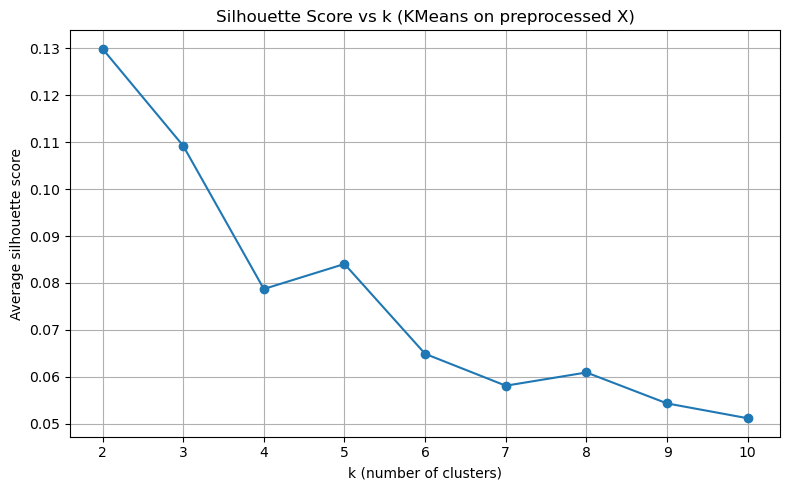

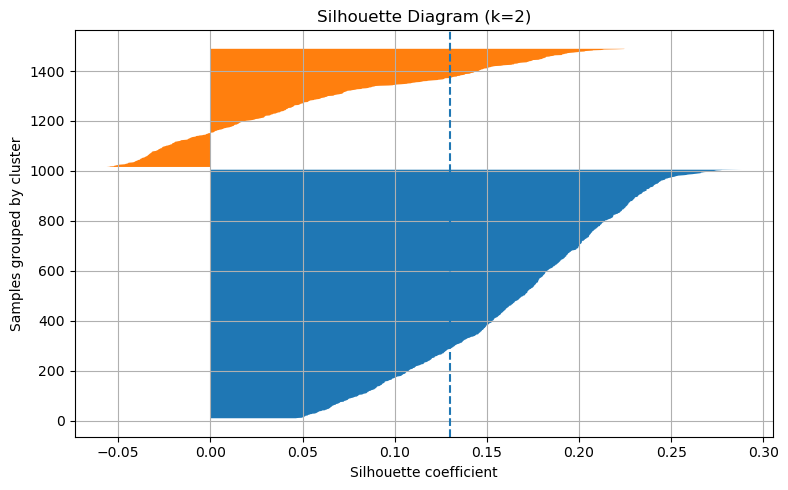

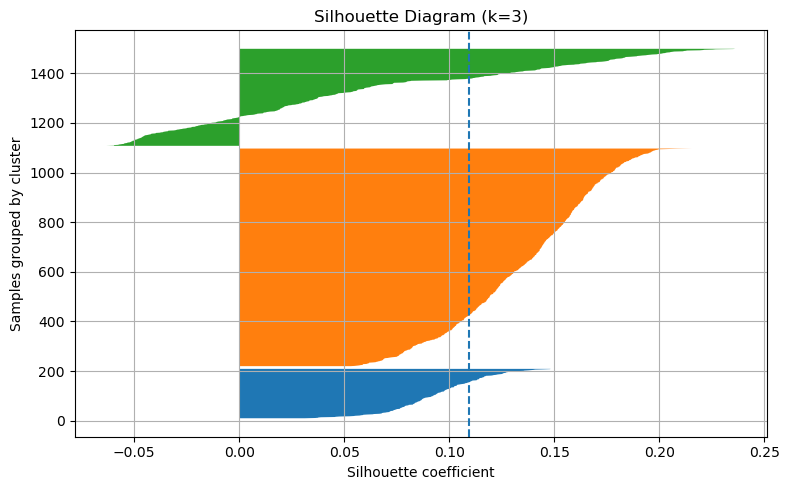

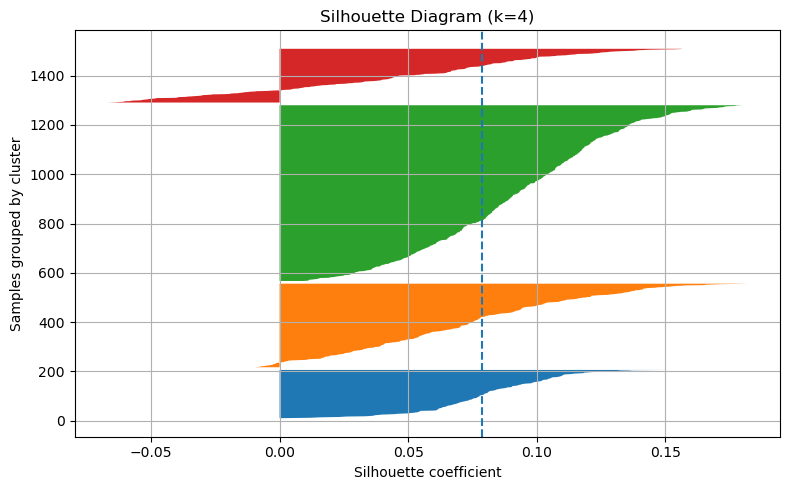

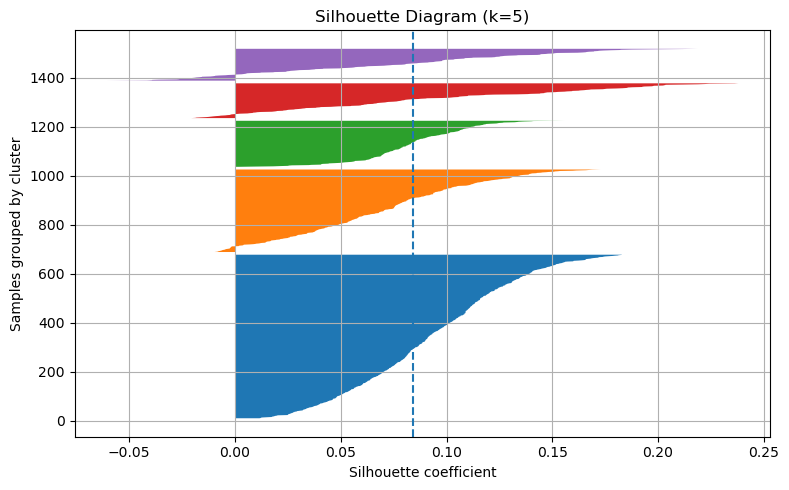

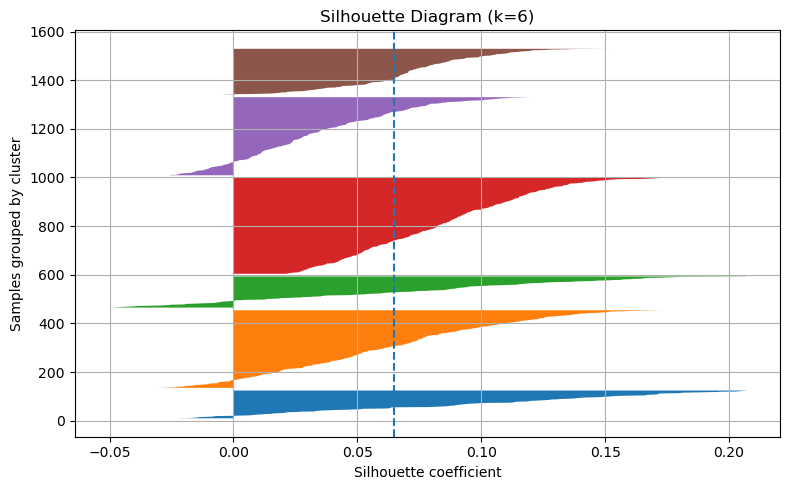

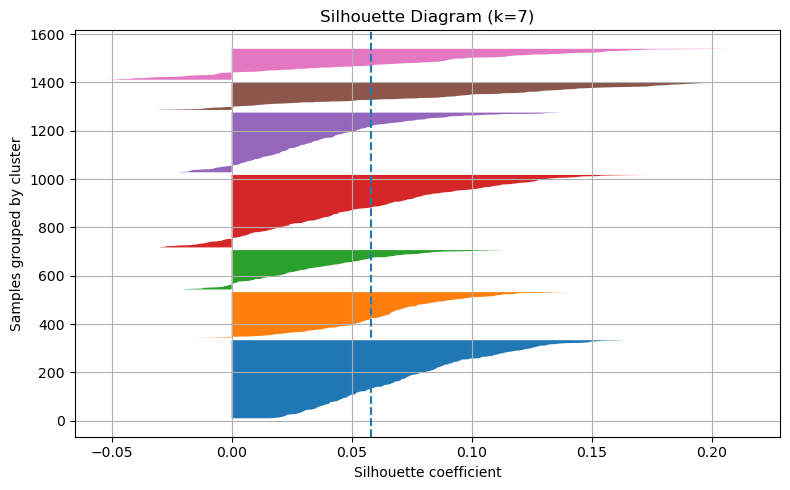

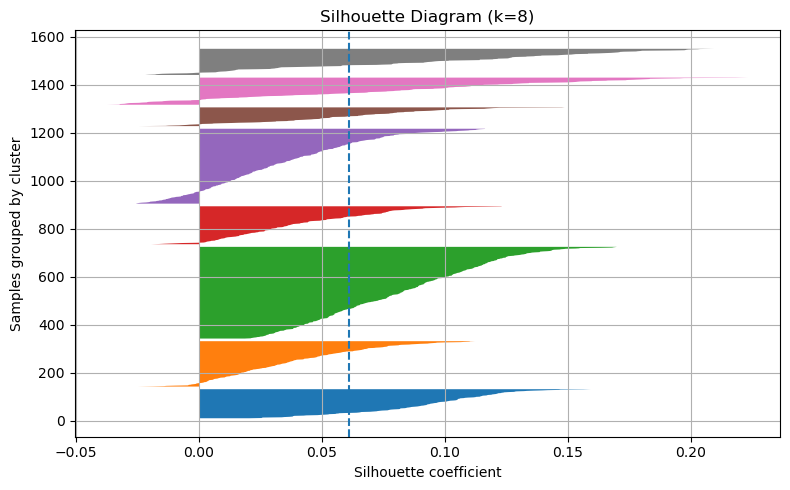

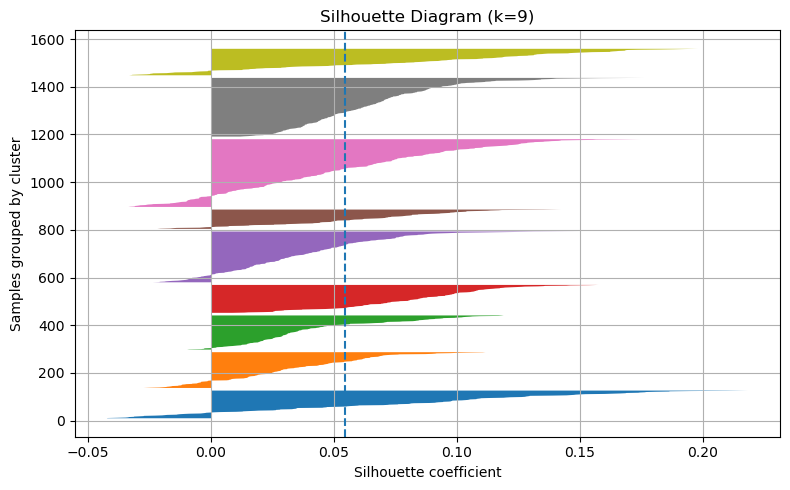

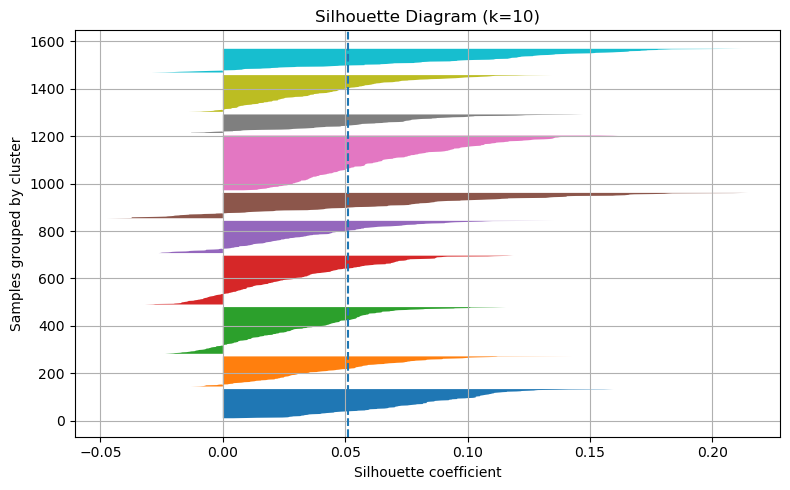

Selected k_star=2 (best_k=2, best_sil=0.130)

=== Cluster Profiles — Numeric Means ===


,Age,DailyRate,DistanceFromHome,Education,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,JobSatisfaction,MonthlyIncome,...,PerformanceRating,RelationshipSatisfaction,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
cluster_k,,,,,,,,,,,,,,,,,,,,,
0,34.16,805.46,9.20,2.83,2.70,66.00,2.72,1.53,2.72,4330.21,...,3.15,2.70,0.76,7.61,2.81,2.75,4.27,2.63,0.99,2.63
1,42.72,796.24,9.18,3.08,2.77,65.66,2.74,3.18,2.75,11068.41,...,3.16,2.73,0.86,18.99,2.78,2.78,12.77,7.58,4.71,7.26



=== Cluster Profiles — Categorical Modes ===


,Attrition,BusinessTravel,Department,EducationField,Gender,JobRole,MaritalStatus,OverTime
cluster_k,,,,,,,,
0,No,Travel_Rarely,Research & Development,Life Sciences,Male,Research Scientist,Married,No
1,No,Travel_Rarely,Research & Development,Life Sciences,Male,Sales Executive,Married,No



Top numeric features by ANOVA F (global):
JobLevel                   1364.28
TotalWorkingYears          1291.90
MonthlyIncome              1190.64
YearsAtCompany             1069.75
YearsInCurrentRole         1013.33
YearsWithCurrManager        856.41
YearsSinceLastPromotion     603.97
Age                         348.72
Education                    18.40
StockOptionLevel              4.05
dtype: float64

Cluster 0: top-3 discriminative numeric features (by |z|): ['JobLevel', 'TotalWorkingYears', 'MonthlyIncome']

Cluster 1: top-3 discriminative numeric features (by |z|): ['JobLevel', 'TotalWorkingYears', 'MonthlyIncome']


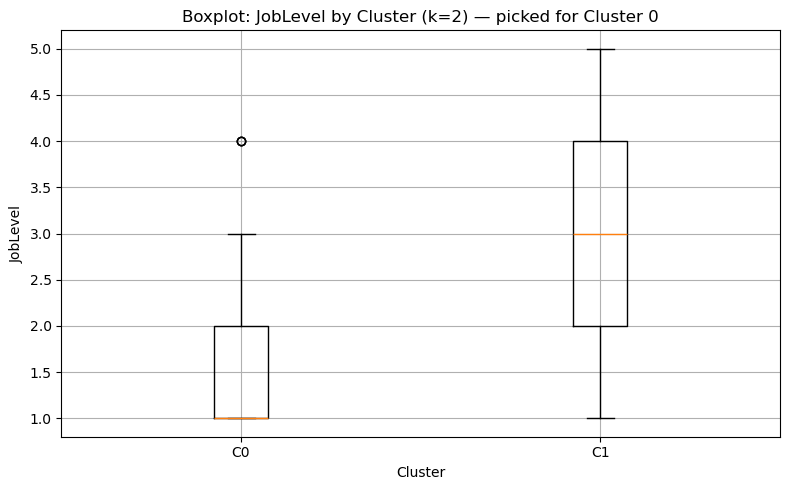

Why 'JobLevel' discriminates for Cluster 0:
- Cluster means by JobLevel: {0: 1.53, 1: 3.18}
- Cluster 0 shows a |z| of 0.48 vs overall, indicating a salient shift.


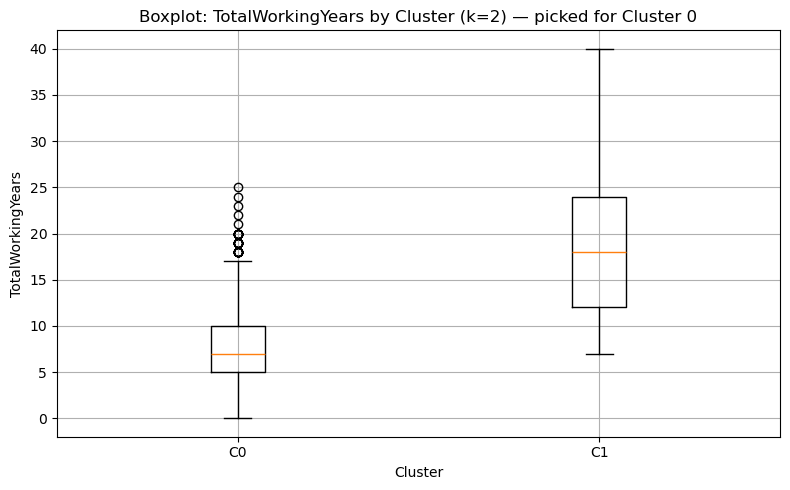

Why 'TotalWorkingYears' discriminates for Cluster 0:
- Cluster means by TotalWorkingYears: {0: 7.61, 1: 18.99}
- Cluster 0 shows a |z| of 0.47 vs overall, indicating a salient shift.


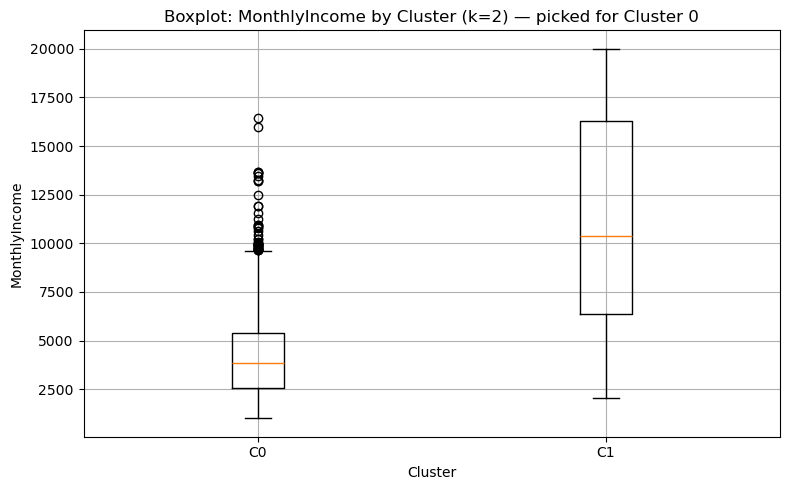

Why 'MonthlyIncome' discriminates for Cluster 0:
- Cluster means by MonthlyIncome: {0: 4330.21, 1: 11068.41}
- Cluster 0 shows a |z| of 0.46 vs overall, indicating a salient shift.


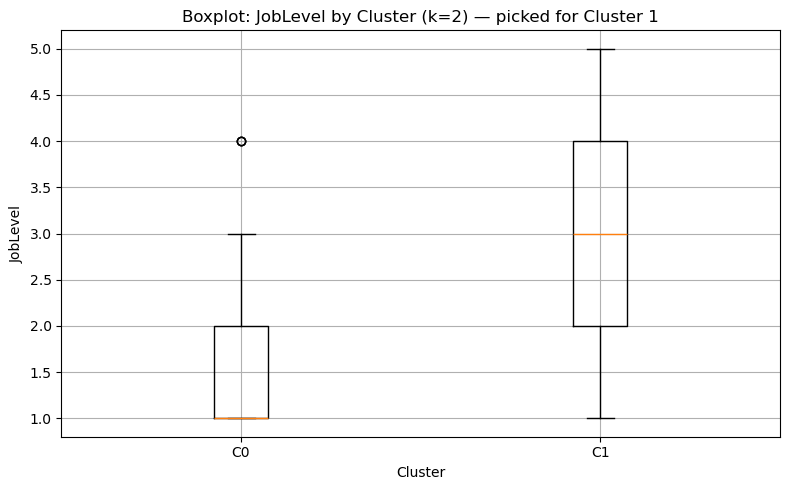

Why 'JobLevel' discriminates for Cluster 1:
- Cluster means by JobLevel: {0: 1.53, 1: 3.18}
- Cluster 1 shows a |z| of 1.01 vs overall, indicating a salient shift.


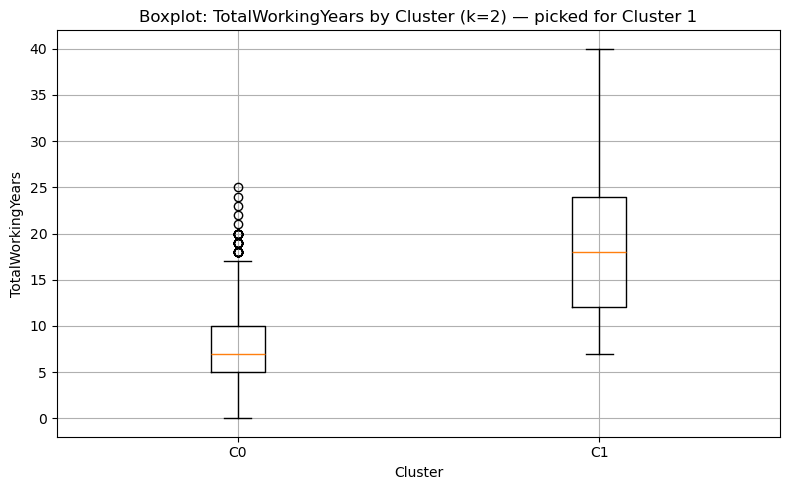

Why 'TotalWorkingYears' discriminates for Cluster 1:
- Cluster means by TotalWorkingYears: {0: 7.61, 1: 18.99}
- Cluster 1 shows a |z| of 0.99 vs overall, indicating a salient shift.


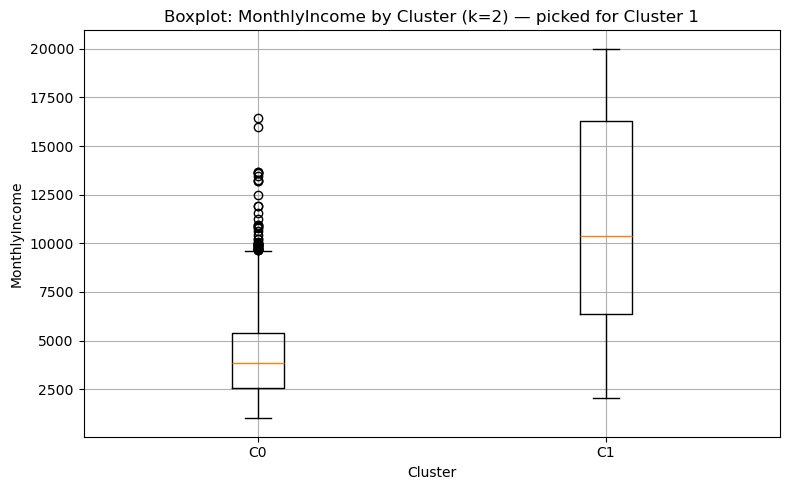

Why 'MonthlyIncome' discriminates for Cluster 1:
- Cluster means by MonthlyIncome: {0: 4330.21, 1: 11068.41}
- Cluster 1 shows a |z| of 0.97 vs overall, indicating a salient shift.
Saved profiles for k=2.


In [29]:
# -----------------------------------------------------------
# 4-a) K selection (k=2..5): metrics, 5 plots, cluster profiles,
#    discriminative-feature boxplots with explanations
# -----------------------------------------------------------


from sklearn.feature_selection import f_classif   # ANOVA F-test to score numeric features
import os                                         # to ensure figs/ dir exists


# Define the k values to explore
k_values =  range(2, 11)

# Containers for results across k
sil_scores = []     # average silhouette per k
labels_per_k = {}   # store labels for each k
models_per_k = {}   # store fitted KMeans models per k

# Compute KMeans, labels, silhouette for each k
for k in k_values:                                              # iterate over candidate k
    km = KMeans(n_clusters=k, n_init=10, random_state=42)       # initialize KMeans
    labels_k = km.fit_predict(X)                                # fit and get labels
    sil_k = silhouette_score(X, labels_k)                       # compute average silhouette
    labels_per_k[k] = labels_k                                  # cache labels
    models_per_k[k] = km                                        # cache model
    sil_scores.append(sil_k)                                    # store silhouette
    print(f"k={k}: silhouette={sil_k:.3f}, inertia={km.inertia_:.1f}")  # quick log line

# ---- PLOT 1 of 5: Silhouette score vs k (overview) ----
plt.figure()                                                     # start new figure
plt.plot(k_values, sil_scores, marker="o")                       # line plot of silhouette vs k
plt.title("Silhouette Score vs k (KMeans on preprocessed X)")    # title
plt.xlabel("k (number of clusters)")                             # x label
plt.ylabel("Average silhouette score")                           # y label
plt.tight_layout()                                               # tidy layout
plt.savefig("figs/4_silhouette_vs_k.png", bbox_inches="tight", dpi=150)  # save PNG
plt.show()                                                       # render inline

# Helper to draw a classic silhouette diagram for a given k
def plot_silhouette_diagram(X_mat, labels_vec, k, savepath):     # define plotting function
    sample_sil = silhouette_samples(X_mat, labels_vec)           # per-sample silhouette coefficients
    y_lower = 10                                                 # start y for first cluster block
    plt.figure()                                                 # new figure
    for i in range(k):                                           # for each cluster
        ith_sil = sample_sil[labels_vec == i]                    # slice values for cluster i
        ith_sil.sort()                                           # sort ascending
        size_i = ith_sil.shape[0]                                # number of samples
        y_upper = y_lower + size_i                               # end y for block
        plt.fill_betweenx(np.arange(y_lower, y_upper), 0, ith_sil)  # filled horizontal bars
        y_lower = y_upper + 10                                   # add gap between clusters
    plt.axvline(x=np.mean(sample_sil), linestyle="--")           # average silhouette reference
    plt.title(f"Silhouette Diagram (k={k})")                     # title
    plt.xlabel("Silhouette coefficient")                         # x label
    plt.ylabel("Samples grouped by cluster")                     # y label
    plt.tight_layout()                                           # tidy layout
    plt.savefig(savepath, bbox_inches="tight", dpi=150)          # save PNG
    plt.show()                                                   # show inline

# ---- PLOTS 2–5 of 5: Silhouette diagrams for k=2..5 ----
for k in k_values:                                               # iterate k=2..5
    plot_silhouette_diagram(
        X_mat=X,
        labels_vec=labels_per_k[k],
        k=k,
        savepath=f"figs/4_silhouette_diagram_k{k}.png"
    )  # draw and save each silhouette diagram

# Decision heuristic to pick a working k_star:
# - If k=2 is clearly dominant, we accept it.
# - Else pick the smallest k whose silhouette is within 0.02 of the best, preferring more granularity.
best_idx = int(np.argmax(sil_scores))                            # index of best silhouette
best_k = k_values[best_idx]                                      # corresponding k
best_sil = sil_scores[best_idx]                                  # best silhouette value

# Initialize k_star with best_k for safety
k_star = best_k                                                  # default to best
# Try to choose a slightly larger k if it yields near-best silhouette (within delta=0.02)
delta = 0.02                                                     # tolerance
for k, s in zip(k_values, sil_scores):                           # walk through (k, silhouette)
    if (s >= best_sil - delta) and (k > 2):                      # near-best and more granular than 2
        k_star = k                                               # choose this k
        break                                                    # stop at the first such k
print(f"Selected k_star={k_star} (best_k={best_k}, best_sil={best_sil:.3f})")  # log selection

# Retrieve labels for the chosen k_star
labels = labels_per_k[k_star]                                    # labels for chosen k
df_with_labels = df.copy()                                       # copy original df (post-cleaning)
df_with_labels["cluster_k"] = labels                             # append cluster labels

# ---- Cluster profiles: numeric means and categorical modes ----
def mode_series(s):                                              # helper to compute mode robustly
    return s.value_counts(dropna=False).index[0]                 # most frequent value

# Numeric profiles (means) per cluster
if len(numeric_cols) > 0:                                        # if numeric columns exist
    prof_num = df_with_labels.groupby("cluster_k")[numeric_cols].mean().round(2)  # means
else:                                                            # else no numerics
    prof_num = pd.DataFrame()                                    # empty frame

# Categorical profiles (modes) per cluster
if len(categorical_cols) > 0:                                    # if categoricals exist
    prof_cat = df_with_labels.groupby("cluster_k")[categorical_cols].agg(mode_series)  # modes
else:                                                            # else no categoricals
    prof_cat = pd.DataFrame()                                    # empty frame

print("\n=== Cluster Profiles — Numeric Means ===")              # header
display(prof_num)                                                # display numeric means
print("\n=== Cluster Profiles — Categorical Modes ===")          # header
display(prof_cat)                                                # display categorical modes

# ---- Discriminative feature mining (numeric): ANOVA F vs cluster labels ----
# We will score numeric features by F-statistic and select top features *per cluster*
# by looking at z-score salience relative to overall mean.

# Compute ANOVA F-scores across all numeric features (global view)
if len(numeric_cols) > 0:                                        # only if numerics exist
    # Build matrix and labels for f_classif
    X_num = df[numeric_cols].values                              # numeric matrix
    y_lbl = labels                                               # cluster labels
    F_vals, p_vals = f_classif(X_num, y_lbl)                     # ANOVA F-test per feature
    f_scores = pd.Series(F_vals, index=numeric_cols).sort_values(ascending=False)  # sort scores
    print("\nTop numeric features by ANOVA F (global):")         # header
    print(f_scores.head(10).round(2))                            # print top 10

    # Compute per-cluster z-salience vs overall (to pick top per cluster)
    overall_mean = df[numeric_cols].mean()                       # overall means per feature
    overall_std = df[numeric_cols].std().replace(0, np.nan)      # std (avoid divide-by-zero)
    z_profiles = (prof_num - overall_mean) / overall_std         # per-cluster z deviations
    z_profiles = z_profiles.replace([np.inf, -np.inf], np.nan)   # clean infs

    # For each cluster, select top-3 most discriminative numeric features by |z|
    topn = 3                                                     # how many features per cluster
    top_feats_per_cluster = {}                                   # dict: cluster -> list of features
    for cl in z_profiles.index:                                  # iterate clusters
        feats = z_profiles.loc[cl].abs().sort_values(ascending=False).head(topn).index.tolist()  # top by |z|
        top_feats_per_cluster[cl] = feats                        # store list
        print(f"\nCluster {cl}: top-{topn} discriminative numeric features (by |z|): {feats}")  # log

    # ---- Boxplots for discriminative features (per cluster, across all clusters) ----
    # We draw one boxplot per feature (showing distribution across clusters).
    for cl, feats in top_feats_per_cluster.items():              # loop clusters and their top features
        for feat in feats:                                       # for each selected feature
            plt.figure()                                         # new figure
            data_to_plot = [df_with_labels.loc[df_with_labels["cluster_k"] == c, feat] for c in sorted(z_profiles.index)]  # gather per-cluster series
            plt.boxplot(data_to_plot, labels=[f"C{c}" for c in sorted(z_profiles.index)])  # draw boxplot
            plt.title(f"Boxplot: {feat} by Cluster (k={k_star}) — picked for Cluster {cl}")  # title
            plt.xlabel("Cluster")                                # x label
            plt.ylabel(feat)                                     # y label
            plt.tight_layout()                                   # tidy
            plt.savefig(f"figs/4_box_{feat}_for_cluster_{cl}.png", bbox_inches="tight", dpi=150)  # save PNG
            plt.show()                                           # inline show

            # Provide an inline textual rationale for why this feature discriminates
            means_by_cluster = df_with_labels.groupby("cluster_k")[feat].mean().round(2)  # means per cluster
            print(f"Why '{feat}' discriminates for Cluster {cl}:")                        # header line
            print(f"- Cluster means by {feat}: {means_by_cluster.to_dict()}")             # show means per cluster
            print(f"- Cluster {cl} shows a |z| of {abs(z_profiles.loc[cl, feat]):.2f} vs overall, indicating a salient shift.")  # z-based rationale
else:
    print("No numeric features available for discriminative boxplots.")                   # message if none

# ---- Optional: quick categorical discriminators (association strength) ----
# For categorical features, a simple heuristic is to compare per-cluster proportions of the mode category.
# For deeper stats, compute chi-square per feature; here we print per-cluster mode already in prof_cat.

# Save profiles to CSV for your repo
if not prof_num.empty:
    prof_num.to_csv(f"cluster_profile_numeric_means_k{k_star}.csv")                       # save numeric profiles
if not prof_cat.empty:
    prof_cat.to_csv(f"cluster_profile_categorical_modes_k{k_star}.csv")                   # save categorical profiles
print(f"Saved profiles for k={k_star}.")                                                  # confirmation


# 5. Dimension Reduction using PCA
 - reduce the dimensions of the dataset
 - Find an appropriate number of PCs to retain
 -

In [21]:
from sklearn.decomposition import PCA  # for dimensionality reduction
from sklearn.preprocessing import StandardScaler  # to standardize numerical features

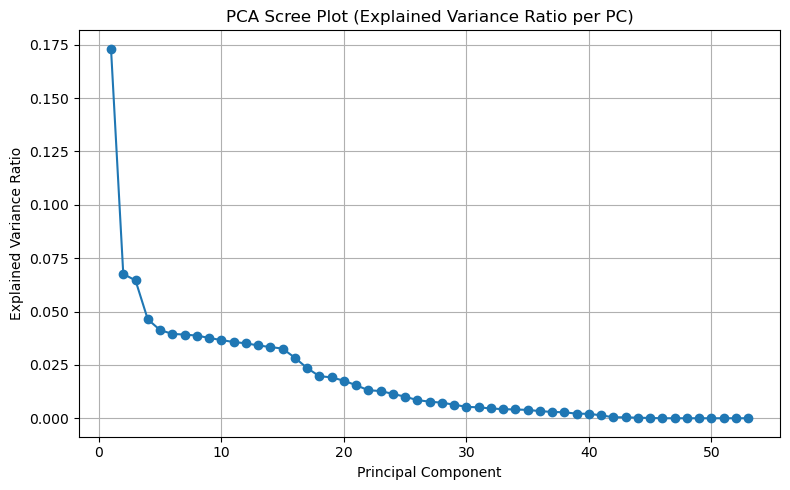

PCs to reach 90% variance: 23


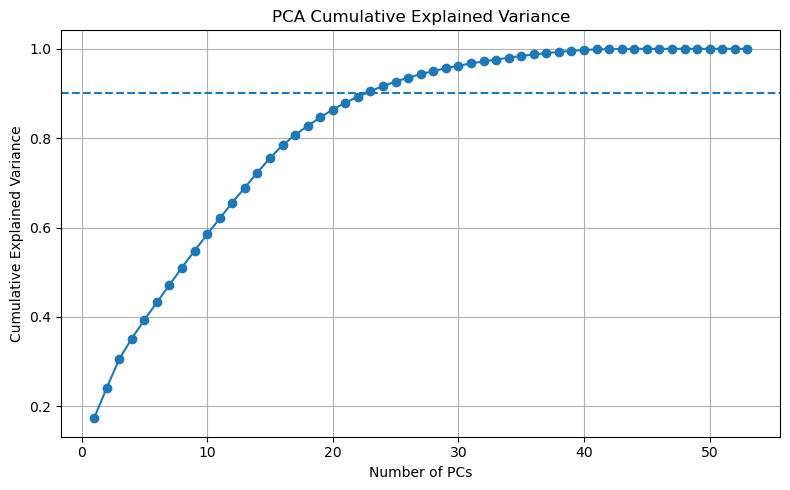

In [22]:
# -----------------------------------------------------------
# 5) PCA analysis; scree & cumulative variance; pick PCs
# -----------------------------------------------------------

# Fit PCA on the preprocessed (OHE+scaled) matrix
pca_full = PCA().fit(X)  # fit PCA keeping all components
explained = pca_full.explained_variance_ratio_  # variance share per component
cum_explained = np.cumsum(explained)  # cumulative explained variance

# Scree plot: eigenvalues proxy (variance explained per component)
plt.figure()  # new figure
plt.plot(np.arange(1, len(explained)+1), explained, marker="o")  # line plot of per-PC variance share
plt.title("PCA Scree Plot (Explained Variance Ratio per PC)")  # title
plt.xlabel("Principal Component")  # x label
plt.ylabel("Explained Variance Ratio")  # y label
plt.tight_layout()  # tidy layout
plt.savefig("figs/pca_scree.png", bbox_inches="tight", dpi=150)  # save PNG
plt.show()  # render inline

# Cumulative explained variance: pick a target threshold (e.g., 90%)
target_var = 0.90  # aim to retain 90% variance (tune to 85-95% as desired)
n_pcs = int(np.searchsorted(cum_explained, target_var) + 1)  # number of PCs to reach threshold
print(f"PCs to reach {int(target_var*100)}% variance:", n_pcs)  # show how many PCs needed

# Plot cumulative variance curve
plt.figure()  # new figure
plt.plot(np.arange(1, len(cum_explained)+1), cum_explained, marker="o")  # cumulative curve
plt.axhline(target_var, linestyle="--")  # reference line for target variance
plt.title("PCA Cumulative Explained Variance")  # title
plt.xlabel("Number of PCs")  # x label
plt.ylabel("Cumulative Explained Variance")  # y label
plt.tight_layout()  # tidy layout
plt.savefig("figs/pca_cumulative.png", bbox_inches="tight", dpi=150)  # save PNG
plt.show()  # render inline


Reflection — Q: Why 90%?\
A: It’s a balanced default: high information retention without overfitting noise. If clusters are fuzzy, try 85%; if structure is strong, 95% can capture nuance.

## 4.b Analysis of Kmeans solution

 - Generate the loadings matrix
 - Are you able to interpret each PC with respect to the original features?
 - Describe your selected PCs from the domain perspective

# 6. Clustering with PCs
 -  perform Kmeans clustering with the PCs
 -  In order to interpret the clusters, you need to revert back to the original features.


In [19]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_samples, silhouette_score

Silhouette (PCA space): 0.14


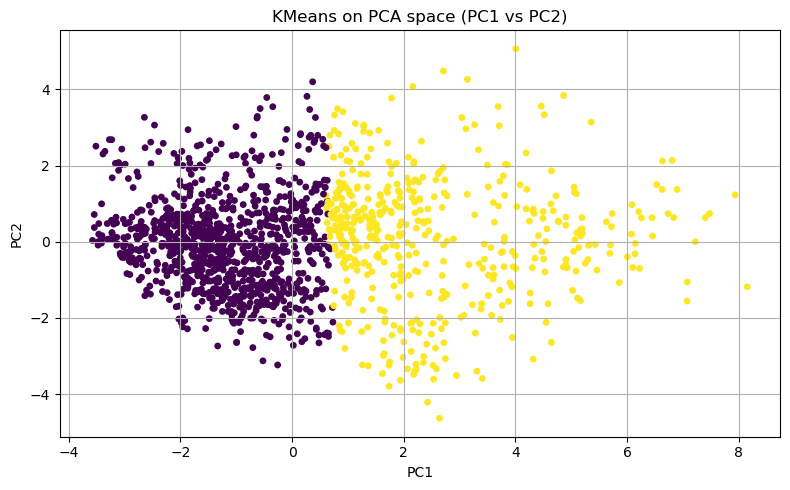


=== Cluster Profiles: Numeric Means ===


,Age,DailyRate,DistanceFromHome,Education,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,JobSatisfaction,MonthlyIncome,...,PerformanceRating,RelationshipSatisfaction,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
cluster_kmeans_pca,,,,,,,,,,,,,,,,,,,,,
0,34.16,804.94,9.20,2.83,2.70,65.97,2.72,1.54,2.72,4334.68,...,3.15,2.70,0.76,7.61,2.81,2.75,4.27,2.64,0.99,2.63
1,42.76,797.30,9.18,3.08,2.77,65.73,2.74,3.18,2.75,11073.22,...,3.15,2.73,0.86,19.01,2.78,2.78,12.78,7.59,4.72,7.26



=== Cluster Profiles: Categorical Modes ===


,Attrition,BusinessTravel,Department,EducationField,Gender,JobRole,MaritalStatus,OverTime
cluster_kmeans_pca,,,,,,,,
0,No,Travel_Rarely,Research & Development,Life Sciences,Male,Research Scientist,Married,No
1,No,Travel_Rarely,Research & Development,Life Sciences,Male,Sales Executive,Married,No



=== Cluster Salience (Numeric Z-scores vs overall) ===


,Age,DailyRate,DistanceFromHome,Education,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,JobSatisfaction,MonthlyIncome,...,PerformanceRating,RelationshipSatisfaction,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
cluster_kmeans_pca,,,,,,,,,,,,,,,,,,,,,
0,-0.30,0.01,0.0,-0.08,-0.02,0.00,-0.01,-0.47,-0.01,-0.46,...,-0.01,-0.01,-0.04,-0.47,0.01,-0.02,-0.45,-0.44,-0.37,-0.42
1,0.64,-0.01,-0.0,0.16,0.04,-0.01,0.01,1.01,0.02,0.97,...,-0.01,0.02,0.08,0.99,-0.01,0.03,0.94,0.93,0.79,0.88


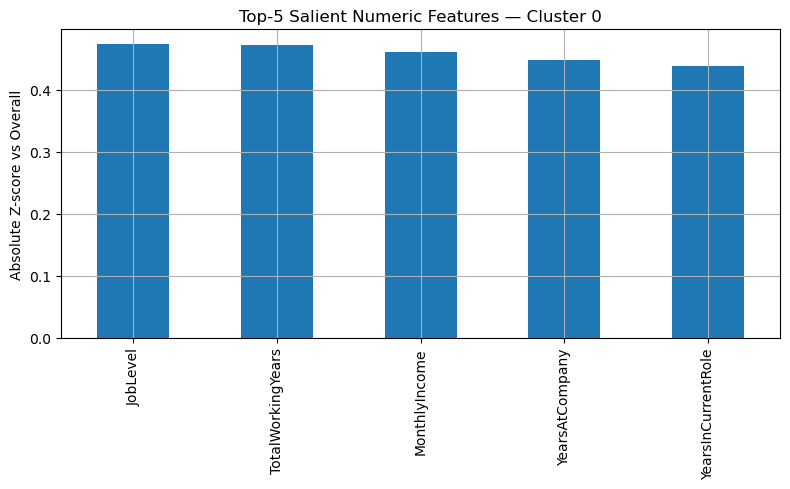

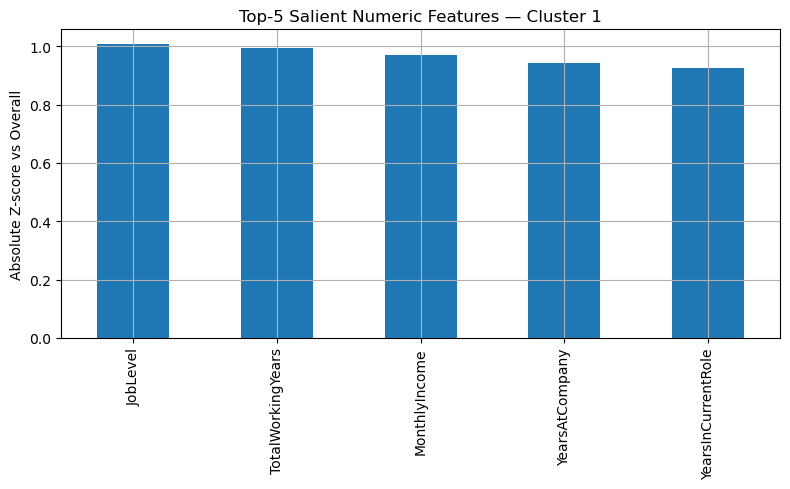

In [23]:
# -----------------------------------------------------------
# 6) KMeans on PCA space; visualize; interpret clusters in original features
# -----------------------------------------------------------

# Project X to the chosen number of principal components
pca = PCA(n_components=n_pcs, random_state=42)  # PCA with selected components
X_pca = pca.fit_transform(X)  # fit PCA and transform X

# Cluster in PCA space using best_k from silhouette earlier
km_pca = KMeans(n_clusters=best_k, n_init=10, random_state=42)  # initialize KMeans
labels_pca = km_pca.fit_predict(X_pca)  # fit and predict labels

# Compute silhouette in PCA space for sanity
sil_pca = silhouette_score(X_pca, labels_pca)  # silhouette on PCs
print("Silhouette (PCA space):", round(sil_pca, 3))  # print silhouette

# Visualize clusters on first two PCs (2D scatter)
plt.figure()  # new figure
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=labels_pca, s=15)  # scatter colored by cluster labels
plt.title("KMeans on PCA space (PC1 vs PC2)")  # title
plt.xlabel("PC1")  # x label
plt.ylabel("PC2")  # y label
plt.tight_layout()  # tidy layout
plt.savefig("figs/pca_scatter_clusters.png", bbox_inches="tight", dpi=150)  # save PNG
plt.show()  # render inline

# Attach cluster labels to original df for interpretation
df_clusters = df.copy()  # copy original (cleaned) df
df_clusters["cluster_kmeans_pca"] = labels_pca  # add cluster labels as a new column

# Summarize numeric features by cluster with means (standard interpretation)
if numeric_cols:  # only if numerics exist
    prof_num = df_clusters.groupby("cluster_kmeans_pca")[numeric_cols].mean().round(2)  # mean per cluster
else:
    prof_num = pd.DataFrame()  # empty if none

# Summarize categorical features by cluster with most frequent category (mode)
def mode_series(s):  # helper to compute mode neatly
    return s.value_counts(dropna=False).index[0]  # return the top category

if categorical_cols:  # only if categoricals exist
    prof_cat = df_clusters.groupby("cluster_kmeans_pca")[categorical_cols].agg(mode_series)  # mode per cluster
else:
    prof_cat = pd.DataFrame()  # empty if none

# Show profiles
print("\n=== Cluster Profiles: Numeric Means ===")  # header
display(prof_num)  # display numeric cluster means
print("\n=== Cluster Profiles: Categorical Modes ===")  # header
display(prof_cat)  # display categorical cluster modes

# Optional: identify "salient" numeric differences by z-score from overall mean
if numeric_cols:  # only if numerics exist
    overall_mean = df[numeric_cols].mean()  # overall means
    overall_std = df[numeric_cols].std().replace(0, np.nan)  # overall stds (avoid divide by zero)
    z_profiles = (prof_num - overall_mean) / overall_std  # z-scores per cluster vs overall
    z_profiles = z_profiles.replace([np.inf, -np.inf], np.nan)  # clean infs
    print("\n=== Cluster Salience (Numeric Z-scores vs overall) ===")  # header
    display(z_profiles.round(2))  # display rounded z-scores

    # Plot top-5 salient features per cluster (absolute z-score)
    for cl in z_profiles.index:  # iterate clusters
        zs = z_profiles.loc[cl].abs().sort_values(ascending=False).head(5)  # top 5 by |z|
        plt.figure()  # new figure
        zs.plot(kind="bar")  # bar plot
        plt.title(f"Top-5 Salient Numeric Features — Cluster {cl}")  # title
        plt.ylabel("Absolute Z-score vs Overall")  # y label
        plt.tight_layout()  # tidy
        plt.savefig(f"figs/top5_salient_cluster_{cl}.png", bbox_inches="tight", dpi=150)  # save PNG
        plt.show()  # render inline


Reflection — Q: Why cluster in PCA space instead of original OHE+scaled space?\
A: PCA can denoise and reduce sparsity (from OHE), often improving KMeans stability. Always profile clusters back on original features to retain interpretability.

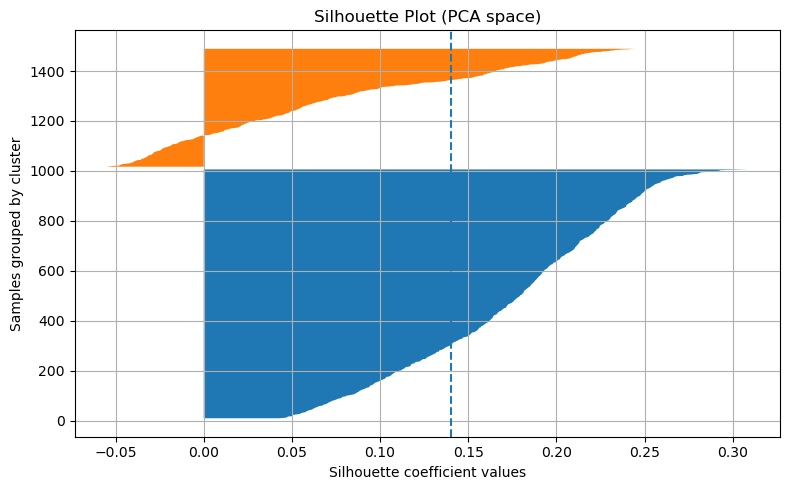

In [25]:
# -----------------------------------------------------------
# 6.1.) Silhouette diagram for chosen k (diagnostic)
# -----------------------------------------------------------

# Compute sample-level silhouette values
sample_sil = silhouette_samples(X_pca, labels_pca)  # silhouette per point

# Silhouette plot (per-cluster distribution)
# (Classic “stacked” silhouette diagram, one per cluster)
y_lower = 10  # starting y position for the first cluster
plt.figure()  # new figure
for i in range(best_k):  # loop each cluster
    ith_sil = sample_sil[labels_pca == i]  # silhouette values for this cluster
    ith_sil.sort()  # sort ascending to stack nicely
    size_i = ith_sil.shape[0]  # number of samples in cluster i
    y_upper = y_lower + size_i  # endpoint for this cluster's bar
    plt.fill_betweenx(np.arange(y_lower, y_upper), 0, ith_sil)  # filled area for cluster silhouette
    y_lower = y_upper + 10  # pad between clusters

plt.axvline(x=np.mean(sample_sil), linestyle="--")  # reference line for average silhouette
plt.title("Silhouette Plot (PCA space)")  # title
plt.xlabel("Silhouette coefficient values")  # x label
plt.ylabel("Samples grouped by cluster")  # y label
plt.tight_layout()  # tidy layout
plt.savefig("figs/silhouette_diagram.png", bbox_inches="tight", dpi=150)  # save PNG
plt.show()  # render inline


Reflection — Q: What is a “good” silhouette?\
A: >0.5 is strong separation, ~0.3–0.5 moderate, <0.25 often suggests poorly separated or overlapping clusters (consider changing k or features).

## 6a Kmeans clustering with Principal Components Analysis
 - Is this a good technical solution?
 - Is this a good business solution in understanding employee attrition?
 - Provide the profile of each cluster

In [26]:
# -----------------------------------------------------------
#  KMeans directly on preprocessed space (baseline)
# -----------------------------------------------------------

# Fit a baseline KMeans on original preprocessed space (X)
km_base = KMeans(n_clusters=best_k, n_init=10, random_state=42)  # initialize baseline KMeans
labels_base = km_base.fit_predict(X)  # fit and get labels
sil_base = silhouette_score(X, labels_base)  # silhouette in original space
print("Silhouette (original preprocessed space):", round(sil_base, 3))  # compare with PCA silhouette

# Compare ARI between PCA-space labels and original-space labels (how consistent are assignments?)
ari_pca_vs_base = adjusted_rand_score(labels_pca, labels_base)  # ARI comparison
print("Adjusted Rand Index (PCA vs Original):", round(ari_pca_vs_base, 3))  # print ARI


Silhouette (original preprocessed space): 0.13
Adjusted Rand Index (PCA vs Original): 0.997


Reflection 1 — Q: Here, ARI is high...\
A: It suggests

Reflection 2 — Q: What if ARI is low between PCA vs Original clusters?\
A: It suggests PCA changed geometry materially (often beneficial). Inspect both profiles and choose the one that yields clearer, actionable business segments.

# 7. K-Prototypes Clustering
 -  refer to this link: https://pypi.org/project/kmodes/
 -  perform kprototype clustering
 -  Note that in kprototypes, you dont need to encode the categorical feature

In [28]:
from kmodes.kprototypes import KPrototypes

ModuleNotFoundError: No module named 'kmodes'

In [24]:
# k-prototypes (will wrap in try/except so notebook runs even if not installed)
try:
    from kmodes.kprototypes import KPrototypes  # k-prototypes clustering for mixed data
    KMODES_AVAILABLE = True  # flag to indicate kmodes is available
except Exception:
    KMODES_AVAILABLE = False  # fallback if kmodes not installed

# Metrics for comparing two clusterings later (KMeans vs k-prototypes)
from sklearn.metrics import adjusted_rand_score  # ARI to compare labelings

from sklearn.preprocessing import minmax_scale
from sklearn.preprocessing import MinMaxScaler  # to scale [0,1] for k-prototypes numeric part

In [27]:
# -----------------------------------------------------------
# 7) k-Prototypes for mixed data (no manual encoding for categoricals)
# -----------------------------------------------------------

# We will try k-prototypes if kmodes is available; otherwise, skip gracefully.
if KMODES_AVAILABLE:  # if kmodes imported successfully
    # Prepare numeric and categorical frames
    df_num = df[numeric_cols].copy() if numeric_cols else pd.DataFrame()  # numeric subset (may be empty)
    df_cat = df[categorical_cols].copy().astype(str) if categorical_cols else pd.DataFrame()  # categorical as str

    # Scale numeric columns to [0,1] for balanced influence in k-prototypes
    if not df_num.empty:  # if numerics exist
        scaler_kp = MinMaxScaler()  # min-max scaler
        df_num_scaled = pd.DataFrame(scaler_kp.fit_transform(df_num), columns=df_num.columns, index=df_num.index)  # scaled numerics
    else:
        df_num_scaled = pd.DataFrame(index=df.index)  # empty DF if no numerics

    # Concatenate numeric (scaled) + categorical (string) preserving column order: numerics first, then categoricals
    df_kp = pd.concat([df_num_scaled, df_cat], axis=1)  # combined mixed-type DataFrame

    # Identify categorical column indices for KPrototypes (these follow numerics)
    cat_start_idx = df_num_scaled.shape[1]  # starting index where categoricals begin
    categorical_idx = list(range(cat_start_idx, df_kp.shape[1]))  # indices of categorical columns

    # Convert to numpy array of mixed types (object)
    X_kp = df_kp.to_numpy()  # numpy array for kmodes API

    # Fit k-prototypes with same number of clusters as best_k (you can also grid-search this)
    kp = KPrototypes(n_clusters=best_k, init="Huang", n_init=5, random_state=42, verbose=0)  # initialize k-prototypes
    labels_kp = kp.fit_predict(X_kp, categorical=categorical_idx)  # fit and predict on mixed data

    # Attach labels and show simple distribution
    df_clusters["cluster_kprototypes"] = labels_kp  # store k-prototypes labels for comparison
    print("k-Prototypes cluster counts:\n", pd.Series(labels_kp).value_counts())  # counts per cluster

    # Compare KMeans(PCA) vs k-prototypes with ARI
    ari_kp_vs_pca = adjusted_rand_score(labels_pca, labels_kp)  # ARI comparison
    print("Adjusted Rand Index (k-prototypes vs KMeans@PCA):", round(ari_kp_vs_pca, 3))  # print ARI

else:
    print("kmodes (k-prototypes) is not installed. Skipping this section.")  # graceful skip
    print("Tip: pip install kmodes  # if your environment permits internet access")  # guidance


kmodes (k-prototypes) is not installed. Skipping this section.
Tip: pip install kmodes  # if your environment permits internet access


## 7a. K-prototype results analysis
 - What are your thoughts and observations about kprototype vs kmeans?
 - Are the results more interpretable?

#### savedown if needed

In [ ]:
# -----------------------------------------------------------
# 8) (OPTIONAL) Save artifacts for Git / further analysis
# -----------------------------------------------------------

# Save the per-cluster numeric means
if numeric_cols:  # only if numerics exist
    prof_num.to_csv("cluster_profile_numeric_means.csv")  # write numeric profiles to CSV

# Save the per-cluster categorical modes
if categorical_cols:  # only if categoricals exist
    prof_cat.to_csv("cluster_profile_categorical_modes.csv")  # write categorical profiles to CSV

# Save row-level assignments (PCA-KMeans) for downstream BI or inspection
assignments = df_clusters[["cluster_kmeans_pca"]]  # take only the labels column
if "Attrition" in df_clusters.columns:  # add Attrition if present for auditing
    assignments = pd.concat([assignments, df_clusters["Attrition"]], axis=1)  # append
assignments.to_csv("row_cluster_assignments.csv", index=False)  # save assignments

print("Saved: cluster_profile_numeric_means.csv, cluster_profile_categorical_modes.csv, row_cluster_assignments.csv")  # confirmation

#use - CSVs diff well in Git, can be pulled into BI tools, and let teammates view results without running the notebook.


## Conclusion:  Write your thoughts and analysis about the above 3 clustering approaches.
 -  Analyze the cluster output from the above methods
 -  Which clustering solution yeilded the most "optimal" way to profile staff attrition?
 -  Why is it considered an "optimal" solution in your opinion?
